In [3]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt

In [4]:
fp32_path = "../../../full_precision/forgeting/experiments"


# Attack forg ep

In [5]:
expath = '../attack_forg_ep'
# results dataset
df = pd.read_parquet(os.path.join(expath,'attack_forg_ep.parquet'))

# attach also fp32
df_fp32 = pd.read_parquet(os.path.join(fp32_path, "attack_forg_ep/attack_forg_ep.parquet")) [['prefix_250', 'prefix_200', 'prefix_150', 'prefix_100', 'suffix',
       '15b_ep0', '15b_ep0_em', '15b_ep0_bleu', '15b_ep0_meteor',
       '15b_ep0_rougeL', '15b_ep1', '15b_ep1_em', '15b_ep1_bleu',
       '15b_ep1_meteor', '15b_ep1_rougeL', '15b_ep2', '15b_ep2_em',
       '15b_ep2_bleu', '15b_ep2_meteor', '15b_ep2_rougeL', '15b_ep3',
       '15b_ep3_em', '15b_ep3_bleu', '15b_ep3_meteor', '15b_ep3_rougeL']]

merged_df = pd.merge(df, df_fp32,
  on=['prefix_250', 'prefix_200',
  'prefix_150', 'prefix_100', 'suffix'],
  how='inner')


## fp32

In [7]:
# Extract and calculate means
metrics = ['em', 'bleu', 'meteor', 'rougeL']
eps = ['ep0', 'ep1', 'ep2', 'ep3']

mean_data = {}


for metric in metrics:
    mean_data[metric] = []
    for ep in eps:
        column_name = f'15b_{ep}_{metric}'
        mean_value = merged_df[column_name].mean()
        mean_data[metric].append(mean_value)

ep_fp32_absolute = pd.DataFrame(mean_data, index=eps)
ep_fp32_absolute

,em,bleu,meteor,rougeL
ep0,0.455,71.476775,0.759458,0.738587
ep1,0.145,52.553449,0.613456,0.583241
ep2,0.143,53.086140,0.618905,0.585694
ep3,0.155,54.476512,0.628973,0.595655


### bf16

In [9]:
# Extract and calculate means
metrics = ['em', 'bleu', 'meteor', 'rougeL']
eps = ['ep0', 'ep1', 'ep2', 'ep3']

mean_data = {}


for metric in metrics:
    mean_data[metric] = []
    for ep in eps:
        column_name = f'bf16_{ep}_{metric}'
        mean_value = df[column_name].mean()
        mean_data[metric].append(mean_value)

ep_bf16_absolute = pd.DataFrame(mean_data, index=eps)
ep_bf16_absolute

,em,bleu,meteor,rougeL
ep0,0.453,71.364470,0.758989,0.738630
ep1,0.142,52.466014,0.613479,0.583261
ep2,0.139,53.132372,0.618834,0.586434
ep3,0.155,54.436846,0.628979,0.595620


In [10]:
# With the baseline
first = ep_bf16_absolute.iloc[0]

ep_bf16_baseline = ep_bf16_absolute.subtract(first)
ep_bf16_baseline

,em,bleu,meteor,rougeL
ep0,0.000,0.000000,0.000000,0.000000
ep1,-0.311,-18.898456,-0.145510,-0.155369
ep2,-0.314,-18.232098,-0.140155,-0.152197
ep3,-0.298,-16.927624,-0.130010,-0.143010


## int8

In [11]:
# Extract and calculate means
metrics = ['em', 'bleu', 'meteor', 'rougeL']
eps = ['ep0', 'ep1', 'ep2', 'ep3']

mean_data = {}


for metric in metrics:
    mean_data[metric] = []
    for ep in eps:
        column_name = f'i8_{ep}_{metric}'
        mean_value = df[column_name].mean()
        mean_data[metric].append(mean_value)

ep_i8_absolute = pd.DataFrame(mean_data, index=eps)
ep_i8_absolute

,em,bleu,meteor,rougeL
ep0,0.457,71.245243,0.757470,0.737002
ep1,0.136,52.115907,0.612202,0.579214
ep2,0.132,52.575198,0.613647,0.582697
ep3,0.155,53.881195,0.624284,0.589536


## i4

In [13]:
# Extract and calculate means
metrics = ['em', 'bleu', 'meteor', 'rougeL']
eps = ['ep0', 'ep1', 'ep2', 'ep3']

mean_data = {}


for metric in metrics:
    mean_data[metric] = []
    for ep in eps:
        column_name = f'i4_{ep}_{metric}'
        mean_value = df[column_name].mean()
        mean_data[metric].append(mean_value)

ep_i4_absolute = pd.DataFrame(mean_data, index=eps)
ep_i4_absolute

,em,bleu,meteor,rougeL
ep0,0.410,69.363641,0.741733,0.718645
ep1,0.132,50.569860,0.598981,0.565115
ep2,0.135,51.264191,0.603737,0.570190
ep3,0.144,51.913691,0.606346,0.572469


## Visuals


In [15]:
df_ep_mem_plot = pd.DataFrame({ 'fp32': ep_fp32_absolute['em'],
                                'bf16': ep_bf16_absolute['em'],
                               'i8': ep_i8_absolute['em'],
                               'i4': ep_i4_absolute['em']})
df_ep_mem_plot

,fp32,bf16,i8,i4
ep0,0.455,0.453,0.457,0.410
ep1,0.145,0.142,0.136,0.132
ep2,0.143,0.139,0.132,0.135
ep3,0.155,0.155,0.155,0.144


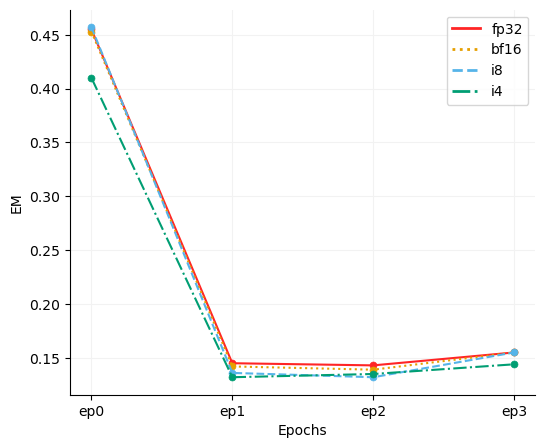

In [17]:
from matplotlib.lines import Line2D
from cycler import cycler

legend_elements = [Line2D([0], [0], lw=2, label='fp32', color='#FF2525', linestyle='-'),
                    Line2D([0], [0], lw=2, label='bf16', color='#E69F00', linestyle=':'),
                   Line2D([0], [0], lw=2, label='i8', color='#56B4E9', linestyle='--'),
                   Line2D([0], [0], lw=2, label='i4', color='#009E73', linestyle='-.')]


fig, ax = plt.subplots(figsize=(6, 5))

# Define colors and linestyles to match legend
labels = ['fp32', 'bf16', 'i8', 'i4']
colors = ['#FF2525', '#E69F00', '#56B4E9', '#009E73']
linestyles = ['-', ':', '--', '-.']
markers = ['o', 'o', 'o', 'o']

for i, label in enumerate(labels):
    # Line
    ax.plot(df_ep_mem_plot.index, df_ep_mem_plot[label], label=label,
            color=colors[i], linestyle=linestyles[i], marker=markers[i],
            markeredgewidth=0.5, markersize=5)

# Hide the all but the bottom spines (axis lines)
ax.spines["right"].set_visible(False)
#ax.spines["left"].set_visible(False)
ax.spines["top"].set_visible(False)

#ax.set_title('Data extraction attack through epochs')

ax.set_xlabel('Epochs')
ax.set_ylabel('EM')
plt.legend(frameon=True, handles=legend_elements)
plt.grid(axis='both', color='0.95', linestyle='-')



plt.show()
fig.savefig('./quant_attack_forg_ep.pdf', format='pdf')

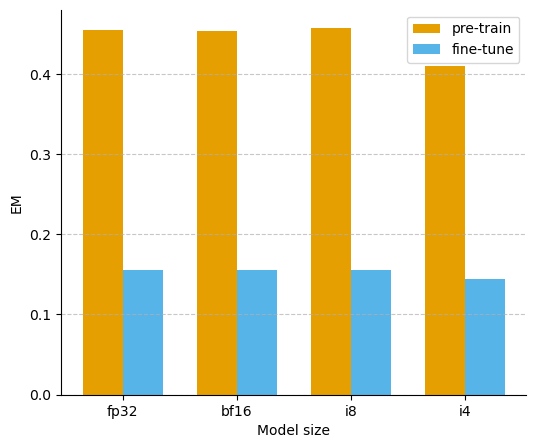

In [23]:
#"#E69F00", "#56B4E9", "#009E73", "#0072B2", "#D55E00", "#CC79A7", "#F0E442"
line_cycler   = (cycler(color=["#FF2525", "#90C4FF", "#009E73", "#0072B2", "#D55E00",  "#F0E442", "#E69F00"]) +
                 cycler(linestyle=["-", "--", "-.", ":", "-", "--", "-."]))

ep0 = df_ep_mem_plot.T['ep0']
ep3 = df_ep_mem_plot.T['ep3']

indices = range(len(ep0))
names = df_ep_mem_plot.T.index

# Calculate optimal width
width = 0.35  # Adjusted to be constant and easy to manage

fig, ax = plt.subplots(figsize=(6, 5))
plt.rc("axes", prop_cycle=line_cycler)

# Plot bars
bar1 = ax.bar(np.array(indices) - width/2, ep0, width, label='pre-train')
bar2 = ax.bar(np.array(indices) + width/2, ep3, width,  label='fine-tune')

# Set the x-ticks and x-tick labels
ax.set_xticks(indices)
ax.set_xticklabels(names)

# Add labels and title
ax.set_xlabel('Model size')
ax.set_ylabel('EM')
# Hide the all but the bottom spines (axis lines)
ax.spines["right"].set_visible(False)
#ax.spines["left"].set_visible(False)
ax.spines["top"].set_visible(False)

ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=6)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Add legend
ax.legend()

plt.show()
fig.savefig('./quant_attack_forget_msize.pdf', format='pdf')

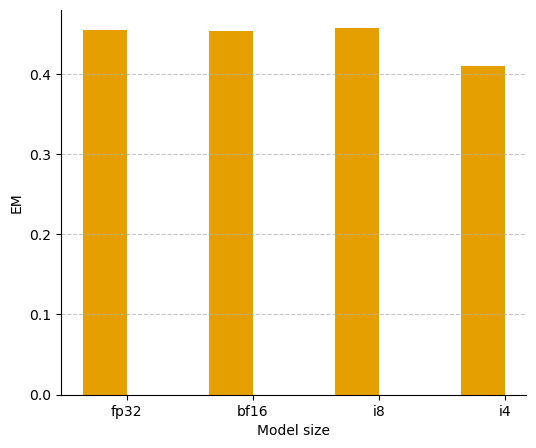

In [105]:
#"#E69F00", "#56B4E9", "#009E73", "#0072B2", "#D55E00", "#CC79A7", "#F0E442"
ep0 = df_ep_mem_plot.T['ep0']

indices = range(len(ep0))
names = df_ep_mem_plot.T.index

# Calculate optimal width
width = 0.35  # Adjusted to be constant and easy to manage

fig, ax = plt.subplots(figsize=(6, 5))

# Plot bars with single color
bar1 = ax.bar(np.array(indices) - width/2, ep0, width, label='pre-train', color='#E69F00')

# Set the x-ticks and x-tick labels
ax.set_xticks(indices)
ax.set_xticklabels(names)

# Add labels and title
ax.set_xlabel('Model size')
ax.set_ylabel('EM')
# Hide the all but the bottom spines (axis lines)
ax.spines["right"].set_visible(False)
#ax.spines["left"].set_visible(False)
ax.spines["top"].set_visible(False)

#ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=6)
ax.grid(axis='y', linestyle='--', alpha=0.7)



plt.show()
fig.savefig('./quant_attack_forget_msize_pre-train.pdf', format='pdf')

# Attack forg plen

In [106]:
expath = '../attack_forg_plen'
# results dataset
df = pd.read_parquet(os.path.join(expath,'attack_forg_plen.parquet'))

# attach also fp32
df_fp32 = pd.read_parquet(os.path.join(fp32_path, "attack_forg_plen/attack_forg_plen.parquet"))

merged_df = pd.merge(df, df_fp32,
  on=['prefix_250', 'prefix_200',
  'prefix_150', 'prefix_100', 'suffix'],
  how='inner')

## fp32

In [107]:
# Extract and calculate means
metrics = ['em', 'bleu', 'meteor', 'rougeL']
plens = ['p100', 'p150', 'p200', 'p250']
eps = ['ep0', 'ep3']

mean_data = {}

for metric in metrics:
    mean_data[metric] = []
    for plen in plens:
        column_name = f'15b_{eps[1]}_{plen}_{metric}'
        mean_value = merged_df[column_name].mean()
        mean_data[metric].append(mean_value)

plen_fp32_absolute = pd.DataFrame(mean_data, index=plens)
plen_fp32_absolute

,em,bleu,meteor,rougeL
p100,0.155,54.476512,0.628973,0.595655
p150,0.198,57.747969,0.657065,0.624595
p200,0.220,59.912378,0.675412,0.645606
p250,0.235,61.837029,0.687467,0.660390


In [83]:
# With the baseline

# compute the baselines
mean_data = {}

for metric in metrics:
    mean_data[metric] = []
    for plen in plens:
        column_name = f'15b_{eps[0]}_{plen}_{metric}'
        mean_value = merged_df[column_name].mean()
        mean_data[metric].append(mean_value)

plen_fp32_ep0 = pd.DataFrame(mean_data, index=plens)
plen_fp32_baseline = plen_fp32_absolute.subtract(plen_fp32_ep0)
plen_fp32_baseline

,em,bleu,meteor,rougeL
p100,-0.300,-17.000262,-0.130486,-0.142932
p150,-0.308,-17.993250,-0.134765,-0.150294
p200,-0.316,-17.756623,-0.130953,-0.148597
p250,-0.314,-17.094791,-0.131974,-0.144755


## bf16

In [108]:
# Extract and calculate means
metrics = ['em', 'bleu', 'meteor', 'rougeL']
plens = ['p100', 'p150', 'p200', 'p250']
eps = ['ep0', 'ep3']

mean_data = {}

for metric in metrics:
    mean_data[metric] = []
    for plen in plens:
        column_name = f'bf16_{eps[1]}_{plen}_{metric}'
        mean_value = merged_df[column_name].mean()
        mean_data[metric].append(mean_value)

plen_bf16_absolute = pd.DataFrame(mean_data, index=plens)
plen_bf16_absolute

,em,bleu,meteor,rougeL
p100,0.155,54.436846,0.628979,0.59562
p150,0.155,54.436846,0.628979,0.59562
p200,0.155,54.436846,0.628979,0.59562
p250,0.155,54.436846,0.628979,0.59562


In [113]:
merged_df[['bf16_ep3_p100_em', 'bf16_ep3_p150_em']]

,bf16_ep3_p100_em,bf16_ep3_p150_em
0,0.0,0.0
1,0.0,0.0
2,0.0,0.0
3,0.0,0.0
4,0.0,0.0
...,...,...
995,0.0,0.0
996,0.0,0.0
997,0.0,0.0
998,0.0,0.0


In [85]:
# With the baseline

# compute the baselines
mean_data = {}

for metric in metrics:
    mean_data[metric] = []
    for plen in plens:
        column_name = f'bf16_{eps[0]}_{plen}_{metric}'
        mean_value = merged_df[column_name].mean()
        mean_data[metric].append(mean_value)

plen_bf16_ep0 = pd.DataFrame(mean_data, index=plens)
plen_bf16_baseline = plen_bf16_absolute.subtract(plen_bf16_ep0)
plen_bf16_baseline

,em,bleu,meteor,rougeL
p100,-0.298,-16.927624,-0.13001,-0.14301
p150,-0.298,-16.927624,-0.13001,-0.14301
p200,-0.298,-16.927624,-0.13001,-0.14301
p250,-0.298,-16.927624,-0.13001,-0.14301


## i8

In [86]:
# Extract and calculate means
metrics = ['em', 'bleu', 'meteor', 'rougeL']
plens = ['p100', 'p150', 'p200', 'p250']
eps = ['ep0', 'ep3']

mean_data = {}

for metric in metrics:
    mean_data[metric] = []
    for plen in plens:
        column_name = f'i8_{eps[1]}_{plen}_{metric}'
        mean_value = merged_df[column_name].mean()
        mean_data[metric].append(mean_value)

plen_i8_absolute = pd.DataFrame(mean_data, index=plens)
plen_i8_absolute

,em,bleu,meteor,rougeL
p100,0.155,53.881195,0.624284,0.589536
p150,0.155,53.881195,0.624284,0.589536
p200,0.155,53.881195,0.624284,0.589536
p250,0.155,53.881195,0.624284,0.589536


In [87]:
# With the baseline

# compute the baselines
mean_data = {}

for metric in metrics:
    mean_data[metric] = []
    for plen in plens:
        column_name = f'i8_{eps[0]}_{plen}_{metric}'
        mean_value = merged_df[column_name].mean()
        mean_data[metric].append(mean_value)

plen_i8_ep0 = pd.DataFrame(mean_data, index=plens)
plen_i8_baseline = plen_i8_absolute.subtract(plen_i8_ep0)
plen_i8_baseline

,em,bleu,meteor,rougeL
p100,-0.302,-17.364048,-0.133186,-0.147465
p150,-0.302,-17.364048,-0.133186,-0.147465
p200,-0.302,-17.364048,-0.133186,-0.147465
p250,-0.302,-17.364048,-0.133186,-0.147465


## i4

In [88]:
# Extract and calculate means
metrics = ['em', 'bleu', 'meteor', 'rougeL']
plens = ['p100', 'p150', 'p200', 'p250']
eps = ['ep0', 'ep3']

mean_data = {}

for metric in metrics:
    mean_data[metric] = []
    for plen in plens:
        column_name = f'i4_{eps[1]}_{plen}_{metric}'
        mean_value = merged_df[column_name].mean()
        mean_data[metric].append(mean_value)

plen_i4_absolute = pd.DataFrame(mean_data, index=plens)
plen_i4_absolute

,em,bleu,meteor,rougeL
p100,0.144,51.913691,0.606346,0.572469
p150,0.144,51.913691,0.606346,0.572469
p200,0.144,51.913691,0.606346,0.572469
p250,0.144,51.913691,0.606346,0.572469


In [89]:
# With the baseline

# compute the baselines
mean_data = {}

for metric in metrics:
    mean_data[metric] = []
    for plen in plens:
        column_name = f'i4_{eps[0]}_{plen}_{metric}'
        mean_value = merged_df[column_name].mean()
        mean_data[metric].append(mean_value)

plen_i4_ep0 = pd.DataFrame(mean_data, index=plens)
plen_i4_baseline = plen_i4_absolute.subtract(plen_i4_ep0)
plen_i4_baseline

,em,bleu,meteor,rougeL
p100,-0.266,-17.44995,-0.135388,-0.146176
p150,-0.266,-17.44995,-0.135388,-0.146176
p200,-0.266,-17.44995,-0.135388,-0.146176
p250,-0.266,-17.44995,-0.135388,-0.146176


## Visuals

In [90]:
df_plen_ep0 = pd.DataFrame({'fp32': plen_fp32_ep0['em'],
                            'bf16': plen_bf16_ep0['em'],
                            'i8': plen_i8_ep0['em'],
                            'i4': plen_i4_ep0['em']
                            })
df_plen_ep0

,fp32,bf16,i8,i4
p100,0.455,0.453,0.457,0.41
p150,0.506,0.453,0.457,0.41
p200,0.536,0.453,0.457,0.41
p250,0.549,0.453,0.457,0.41


In [91]:
df_plen_ep3 = pd.DataFrame({'fp32': plen_fp32_absolute['em'],
                            'bf16': plen_bf16_absolute['em'],
                            'i8': plen_i8_absolute['em'],
                            'i4': plen_i4_absolute['em']
                            })
df_plen_ep3

,fp32,bf16,i8,i4
p100,0.155,0.155,0.155,0.144
p150,0.198,0.155,0.155,0.144
p200,0.220,0.155,0.155,0.144
p250,0.235,0.155,0.155,0.144


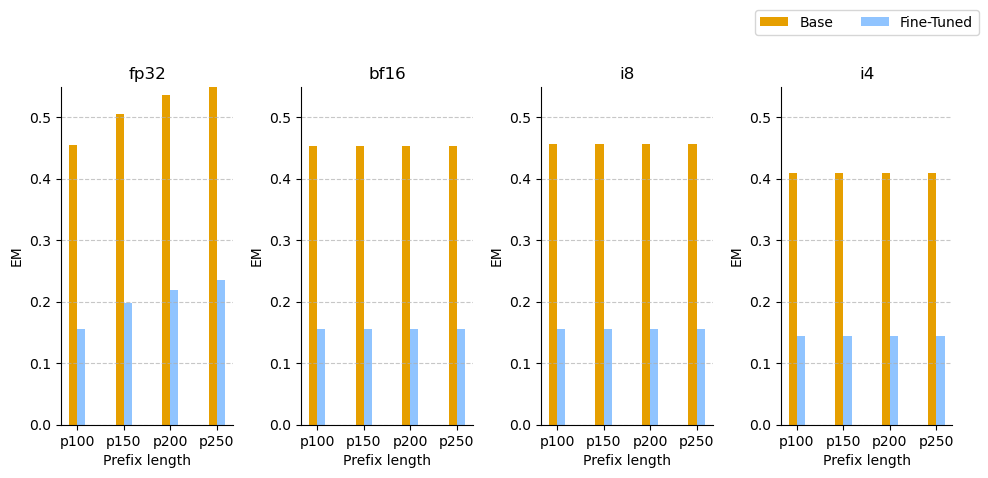

In [100]:
line_cycler   = (cycler(color=["#90C4FF", "#009E73", "#0072B2", "#D55E00",  "#F0E442", "#E69F00", "#FF2525"]) +
                 cycler(linestyle=["-", "--", "-.", ":", "-", "--", "-."]))



fig, axes = plt.subplots(1, 4, figsize=(10, 5))  # Increased figure width
axes = axes.flatten()


# Number of bars (prefix lengths)
num_bars = len(df_plen_ep0.index)
bar_width = 0.35

# Define a color palette
labels = ['fp32', 'bf16', 'i8', 'i4']
max_value = max(df_plen_ep0.max().max(), df_plen_ep3.max().max())

# Define positions for the bars
bar_positions = np.arange(num_bars)  # x positions for bars

for i, label in enumerate(labels):
    ax = axes[i]

    # Define width for each group
    width = bar_width / 2  # Since there are two groups for each label (ptrain and ftune)

    # Positions for the bars in this group
    positions_ep0 = bar_positions - width / 2  # center align ptrain bars
    positions_ep3 = bar_positions + width / 2  # center align ftune bars

    ax.bar(positions_ep0, df_plen_ep0[label], width, label='Base', color='#E69F00')
    ax.bar(positions_ep3, df_plen_ep3[label], width, label='Fine-Tuned', color='#90C4FF')

    # Hide all but the bottom spines (axis lines)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)

    ax.set_xlabel('Prefix length')
    ax.set_ylabel('EM')
    ax.set_title(f'{label}')

    #ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2)

    # Set the same y-axis limit
    ax.set_ylim(0, max_value)

    # Set x-ticks to the center of the bars
    ax.set_xticks(bar_positions)
    ax.set_xticklabels(df_plen_ep0.index)

    # Optional grid
    ax.grid(axis='y', linestyle='--', alpha=0.7)

#plt.legend(bbox_to_anchor=(1, 1))
#plt.legend(loc='upper left', bbox_to_anchor=(-2.4, 1.3), ncol=2)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.25), ncol=2)
plt.tight_layout()
plt.show()
fig.savefig('./quant_attack_forget_plen.pdf', format='pdf')

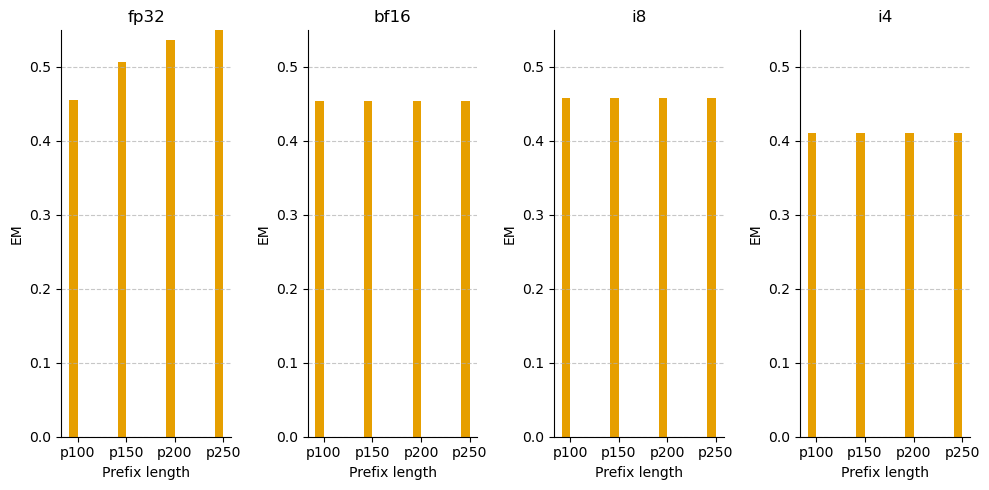

In [102]:
fig, axes = plt.subplots(1, 4, figsize=(10, 5))  # Increased figure width
axes = axes.flatten()


# Number of bars (prefix lengths)
num_bars = len(df_plen_ep0.index)
bar_width = 0.35

# Define a color palette
labels = ['fp32', 'bf16', 'i8', 'i4']
max_value = max(df_plen_ep0.max().max(), df_plen_ep3.max().max())

# Define positions for the bars
bar_positions = np.arange(num_bars)  # x positions for bars

for i, label in enumerate(labels):
    ax = axes[i]

    # Define width for each group
    width = bar_width / 2  # Since there are two groups for each label (ptrain and ftune)

    # Positions for the bars in this group
    positions_ep0 = bar_positions - width / 2  # center align ptrain bars
    # positions_ep3 = bar_positions + width / 2  # center align ftune bars

    ax.bar(positions_ep0, df_plen_ep0[label], width, label='Base', color='#E69F00')
    #ax.bar(positions_ep3, df_plen_ep3[label], width, label='Fine-Tuned', color='#90C4FF')

    # Hide all but the bottom spines (axis lines)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)

    ax.set_xlabel('Prefix length')
    ax.set_ylabel('EM')
    ax.set_title(f'{label}')

    #ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2)

    # Set the same y-axis limit
    ax.set_ylim(0, max_value)

    # Set x-ticks to the center of the bars
    ax.set_xticks(bar_positions)
    ax.set_xticklabels(df_plen_ep0.index)

    # Optional grid
    ax.grid(axis='y', linestyle='--', alpha=0.7)

#plt.legend(bbox_to_anchor=(1, 1))
#plt.legend(loc='upper left', bbox_to_anchor=(-2.4, 1.3), ncol=2)
#plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.25), ncol=2)
plt.tight_layout()
plt.show()
fig.savefig('./quant_attack_forget_plen_pre.pdf', format='pdf')